In [69]:
print ("Hello, World!")

Hello, World!


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from xgboost import XGBClassifier
import pickle

In [71]:
df=pd.read_csv("D:\\DSA\\pythonForML\\archive (5)\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [72]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
df.shape

(7043, 21)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


count missing values per column

In [75]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

count missing values per row

In [76]:
df.isna().sum(axis=1)

0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Length: 7043, dtype: int64

In [77]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

dropping customerid not needed in future

In [78]:
df=df.drop("customerID",axis=1)

In [79]:
numerical_feature_list=["tenure","MonthlyCharges","TotalCharges"]
for col in df.columns:
    if col not in numerical_feature_list:
        print(col,df[col].unique())
        print("--------------------")

gender ['Female' 'Male']
--------------------
SeniorCitizen [0 1]
--------------------
Partner ['Yes' 'No']
--------------------
Dependents ['No' 'Yes']
--------------------
PhoneService ['No' 'Yes']
--------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------
StreamingTV ['No' 'Yes' 'No internet service']
--------------------
StreamingMovies ['No' 'Yes' 'No internet service']
--------------------
Contract ['Month-to-month' 'One year' 'Two year']
--------------------
PaperlessBilling ['Yes' 'No']
--------------------
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [80]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [81]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0.0")

In [82]:
df["TotalCharges"]= df["TotalCharges"].astype(float)

In [83]:
len(df[df["TotalCharges"]==' '])

0

In [84]:
df[df["TotalCharges"]==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


checking the distribution of target column

In [86]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

INSIGHTS
1. remove customer id not required for modelling
2.No missing values in dataset
3.missing values in total charges colimnbs replaced with 0
4.class imbalance identified in the target 

exploratory data analysis(EDA)

In [87]:
df.shape

(7043, 20)

In [88]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [89]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


understand the distribution of numerical features

In [90]:
def plot_histogram(df,column_name):
    plt.figure(figsize=(8,5))
    sns.histplot(df[column_name],kde=True,bins=30)
    plt.title(f"Distribution of {column_name}")
#calculate mean and median
    col_mean=df[column_name].mean()
    col_median=df[column_name].median()
    #add vertical lines for mean and median
    plt.axvline(col_mean,color='r',linestyle='--',label='Mean',linewidth=1)
    plt.axvline(col_median,color='g',linestyle='-',label='Median',linewidth=1)
    plt.legend()
    plt.show()

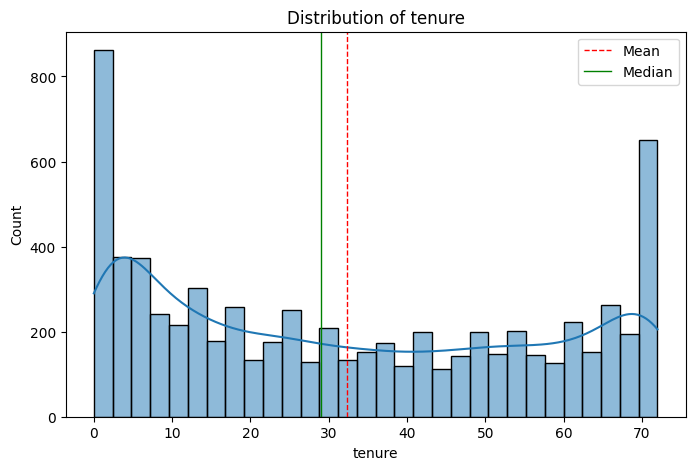

In [91]:
plot_histogram(df,"tenure")

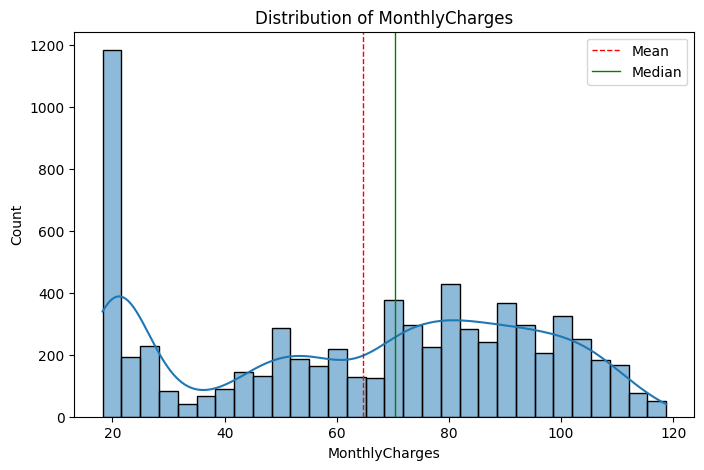

In [92]:
plot_histogram(df,"MonthlyCharges")

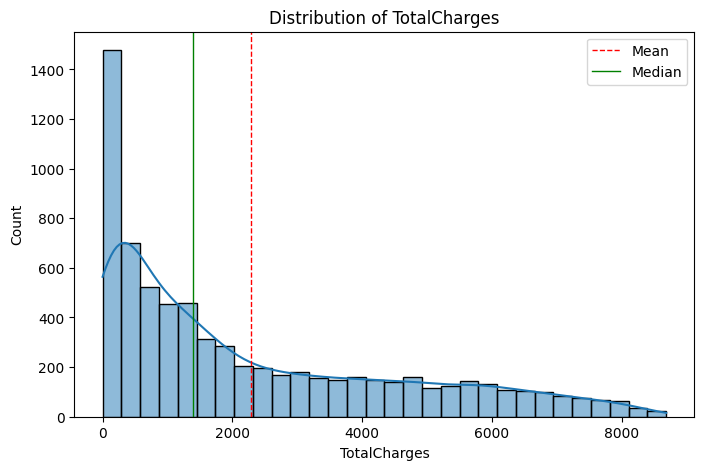

In [93]:
plot_histogram(df,"TotalCharges")

box plot is used to identitfy the outliers

In [94]:
def plot_boxplot(df,column_name):
    plt.figure(figsize=(8,5))
    sns.boxplot(y=df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

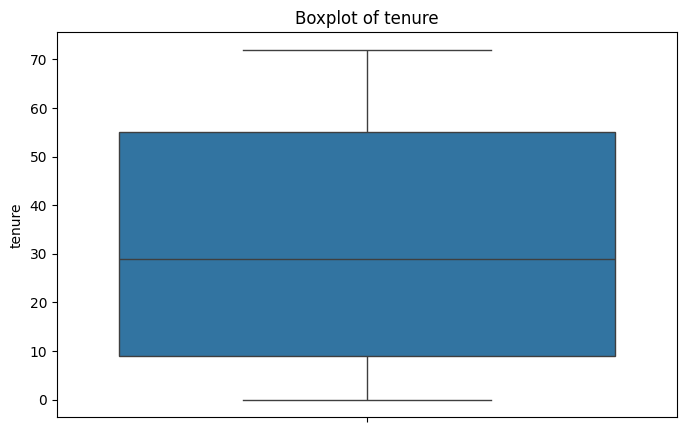

In [95]:
plot_boxplot(df,"tenure")

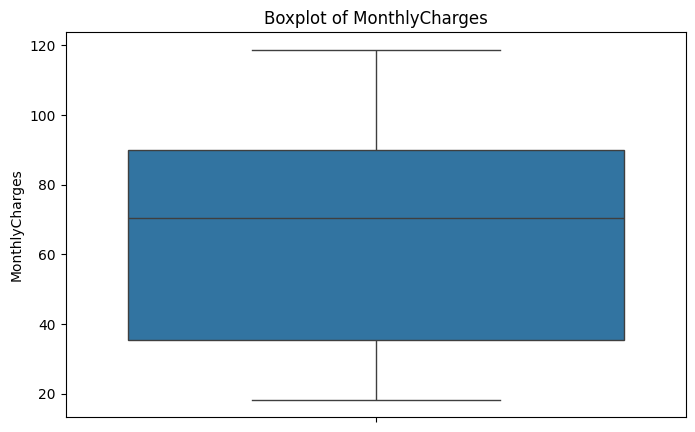

In [96]:
plot_boxplot(df,"MonthlyCharges")

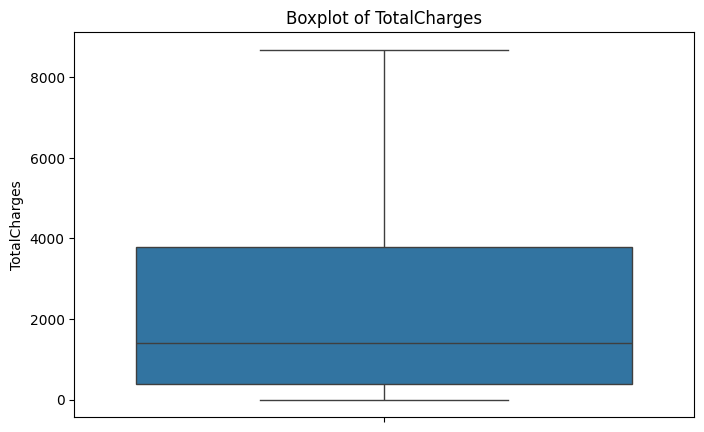

In [97]:
plot_boxplot(df,"TotalCharges")

correlation heatmap for numerical relations

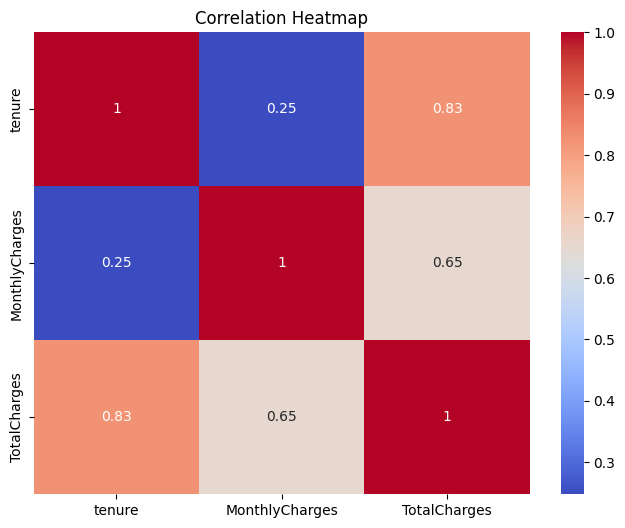

In [98]:
#correlation matrix-heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

💡 Quick Insights

Diagonal values are always 1.0 (a column is always perfectly correlated with itself).

You mainly look at off-diagonal cells to find meaningful relationships.

High correlation (>0.7) → strong linear relationship (good for prediction).

Low correlation (near 0) → weak or no relationship.

Each square shows the relationship strength between two columns:

Example	Interpretation
tenure ↔ TotalCharges = 0.82	Strong positive — longer tenure → higher total charges
tenure ↔ MonthlyCharges = 0.20	Weak positive — monthly bill slightly increases with tenure
MonthlyCharges ↔ TotalCharges = 0.65	Moderate positive — total increases with monthly bill

In [99]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [101]:
object_cols=df.select_dtypes(include=['object']).columns.tolist()
object_cols=["SeniorCitizen"]+object_cols
object_cols

['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

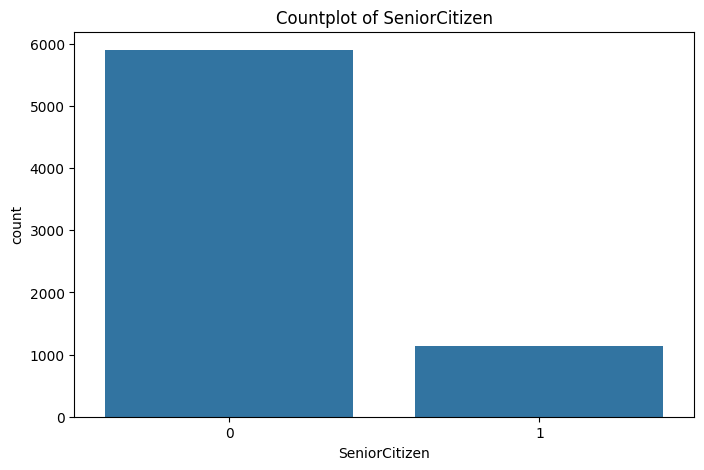

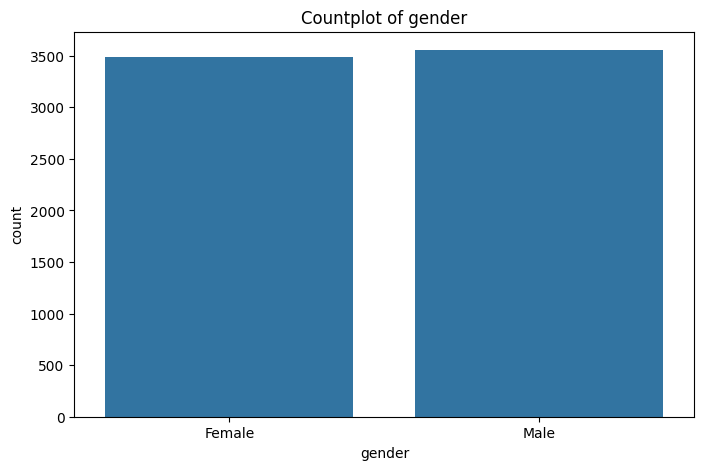

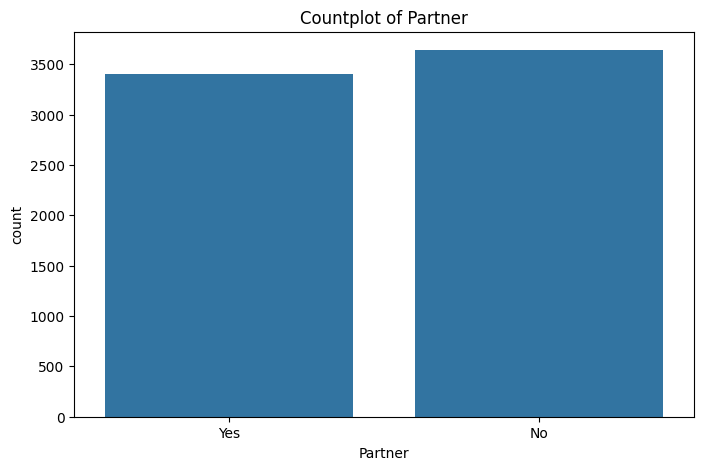

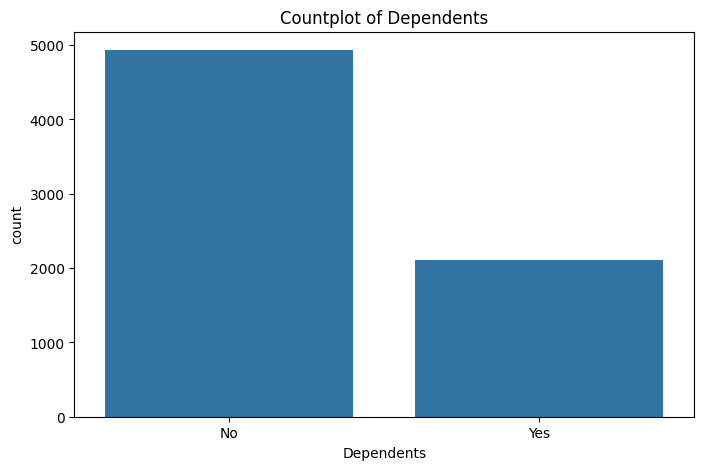

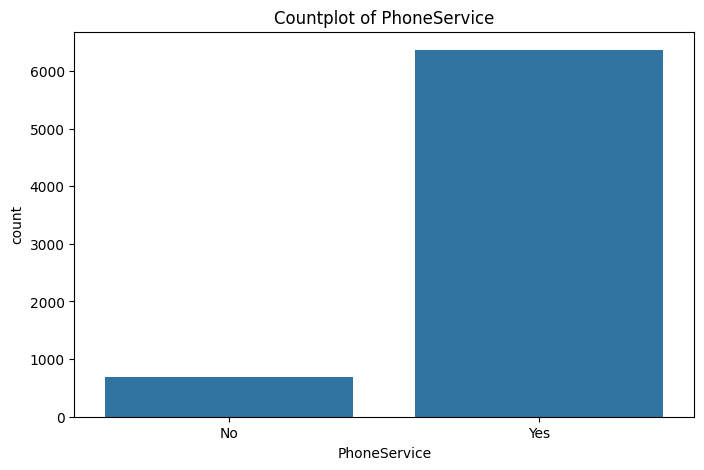

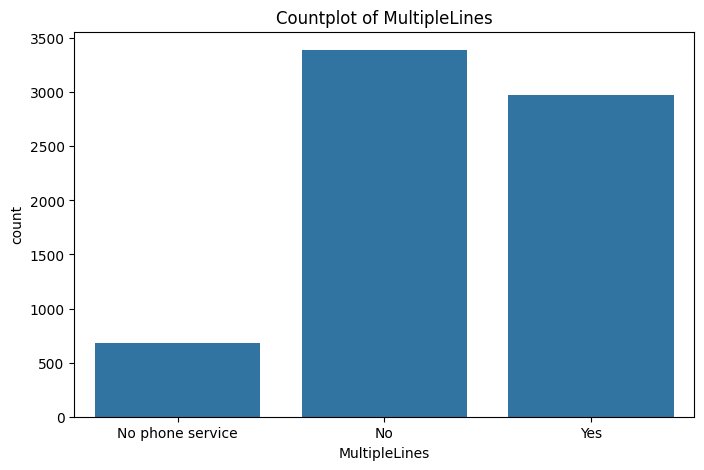

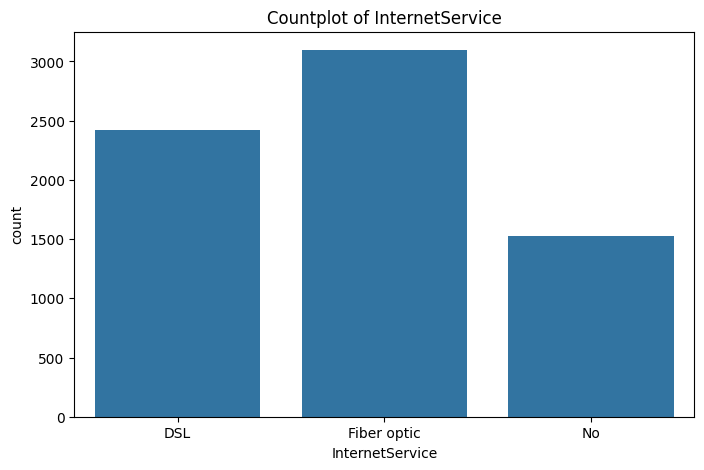

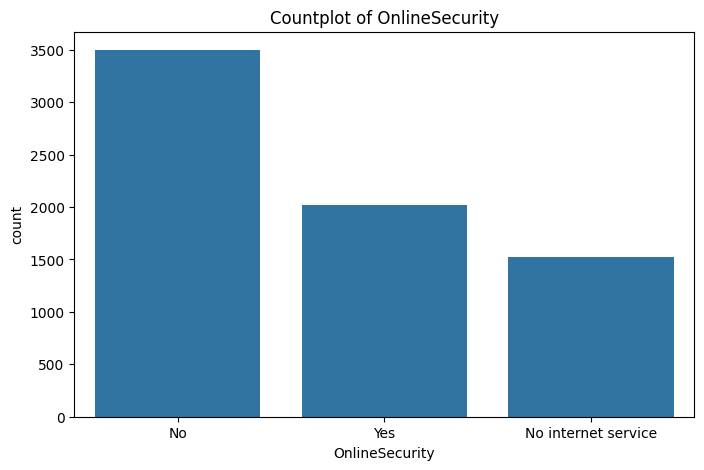

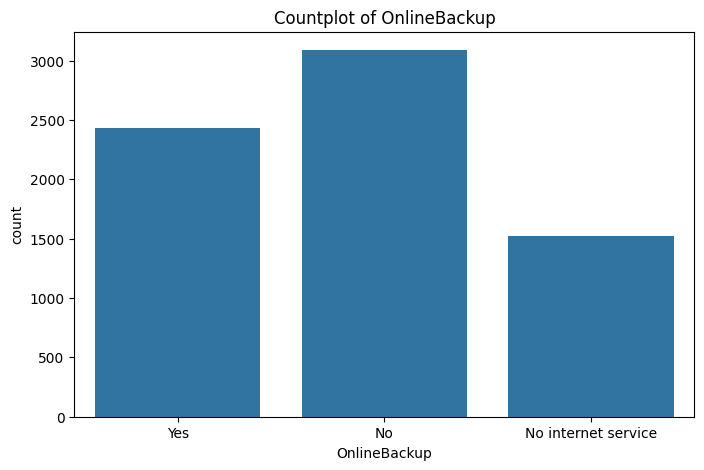

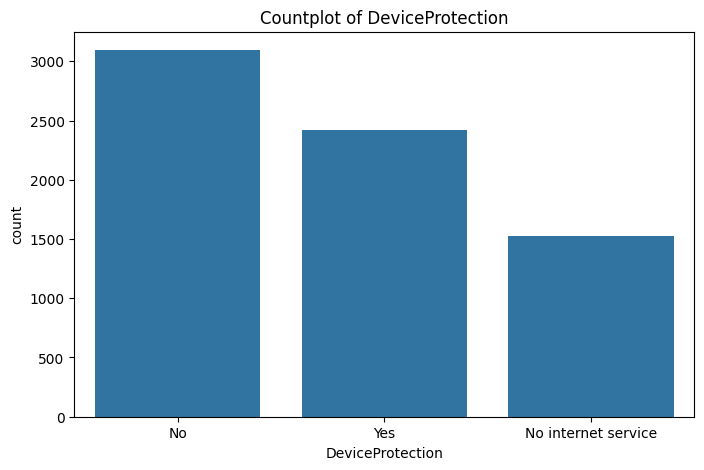

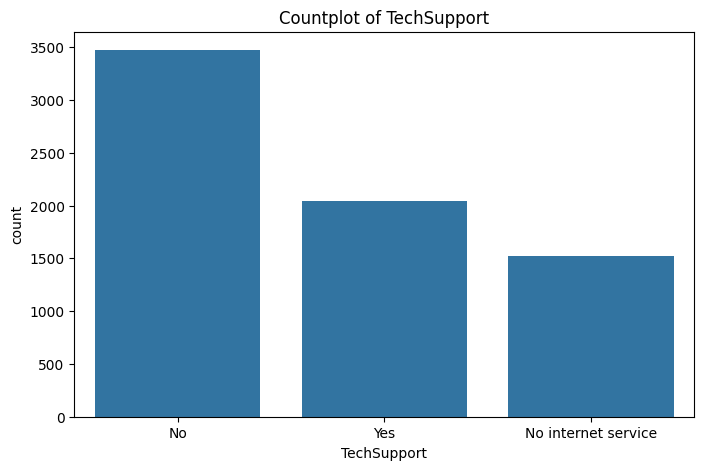

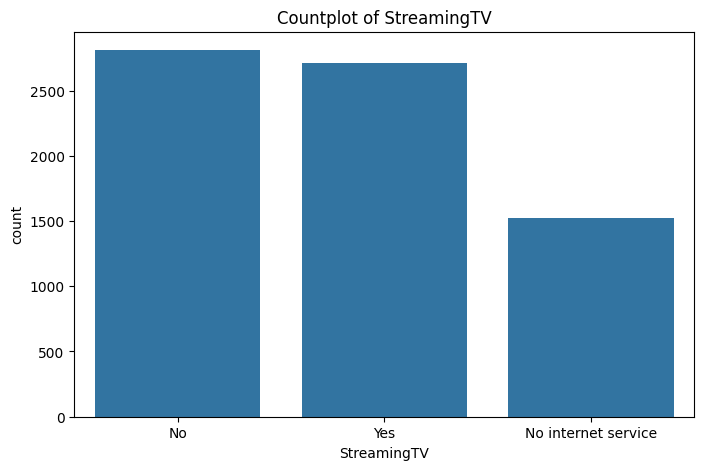

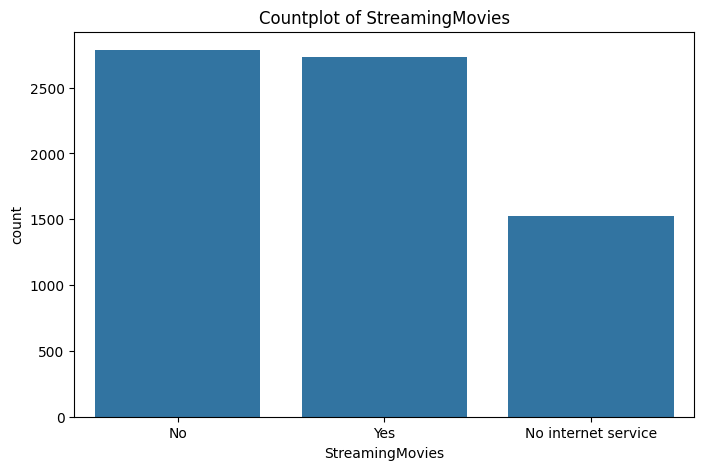

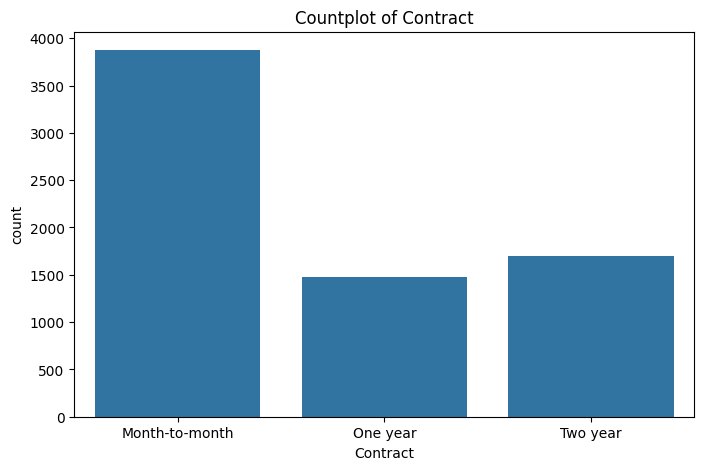

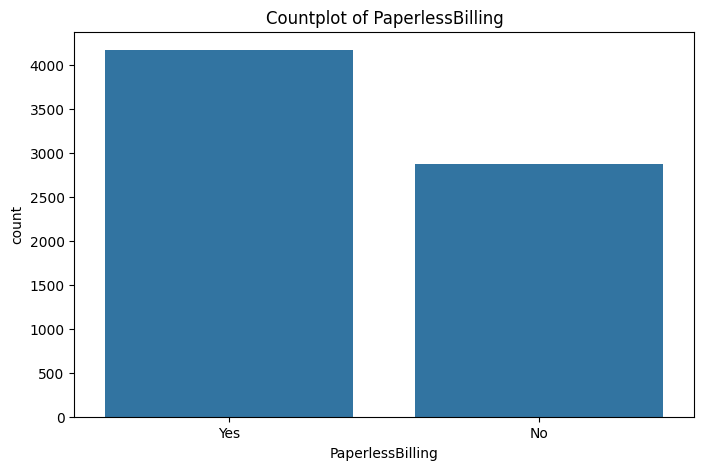

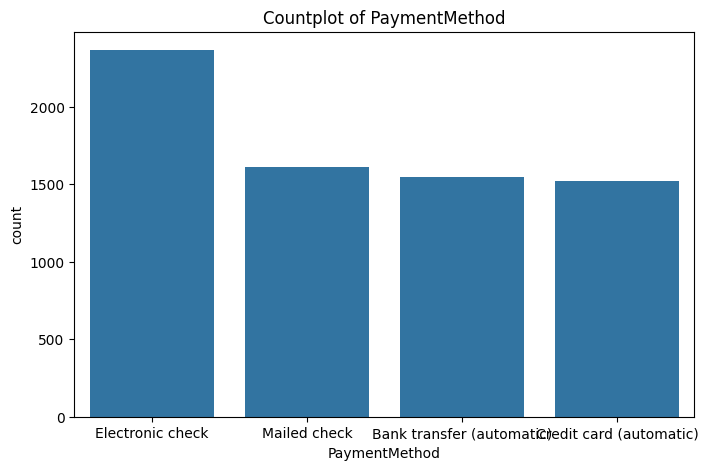

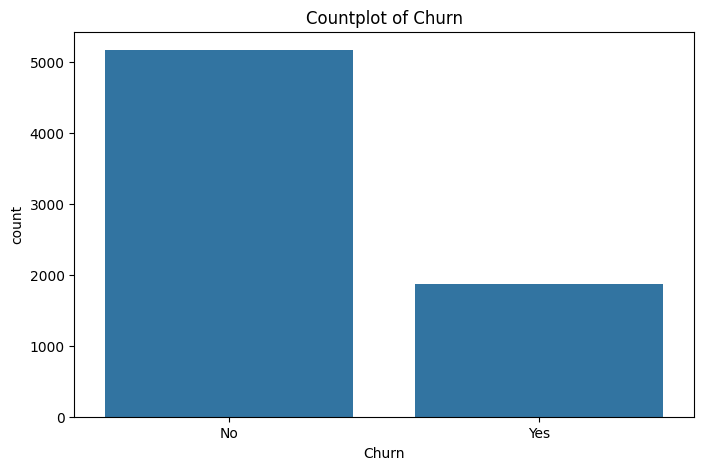

In [102]:
for col in object_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()

data preprocessing

In [103]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


label encoding of target column

In [104]:
df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})

In [105]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [106]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

label encoding of categorical features

In [107]:
#identifying column with object datatypes
categorical_cols=df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [108]:
#initialize a dictionary to hold label encoders
encoders={}
for col in categorical_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoders[col]=le
#save the encoders dictionary to a file using pickle
with open("encoders.pkl","wb") as f:
    pickle.dump(encoders,f)

In [109]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [110]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


training and test data split

In [111]:
#splitting features and target variable
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [112]:
print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [113]:
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [114]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [115]:
print(y_train.shape)


(5634,)


In [116]:
print(y_train.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


In [117]:
print(y_train)

3738    0
3151    0
4860    0
3867    0
3810    0
       ..
6303    0
6227    1
4673    1
2710    0
5639    0
Name: Churn, Length: 5634, dtype: int64


Synthetic minority oversampling technique (SMOTE)

🎯 Problem that SMOTE solves

In many real-world datasets, one class (minority) has far fewer samples than the other (majority).
Example: Fraud detection

Legit transactions: 98,000

Fraudulent transactions: 2,000

A model trained on such data will learn to always predict “Legit” — giving high accuracy but poor recall for frauds.

This is called a class imbalance problem.

💡 What SMOTE does

Instead of just duplicating minority samples, SMOTE creates new synthetic samples (fake but realistic data points) by interpolating between existing minority points.

In [118]:
smote=SMOTE(random_state=42)

In [119]:
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

In [120]:
print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


Model training

Training with default hyperparameters

In [121]:
models={
    "RandomForest":RandomForestClassifier(random_state=42),
    "DecisionTree":DecisionTreeClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42,use_label_encoder=False)}

#dictionary to store cross validation resultd

In [122]:
cv_scores={}  #dictionary to store cross validation results
for model_name,model in models.items():
    print(f"Training {model_name} with default paras")
    scores=cross_val_score(model,X_train_smote,y_train_smote,cv=5,scoring='accuracy')
    cv_scores[model_name]=scores.mean()
    #print(f"Mean accuracy: {cv_scores[model_name]}")
    print(f"Model: {model_name} cross validation accuracy:{np.mean(scores):.2f}")


Training RandomForest with default paras
Model: RandomForest cross validation accuracy:0.84
Training DecisionTree with default paras
Model: DecisionTree cross validation accuracy:0.78
Training XGBoost with default paras


c:\Users\Charu Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [06:42:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Charu Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [06:42:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Charu Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [06:42:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBoost cross validation accuracy:0.83


c:\Users\Charu Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [06:42:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Charu Sharma\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [06:42:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [123]:
cv_scores

{'RandomForest': 0.8398280718653766,
 'DecisionTree': 0.784862078024432,
 'XGBoost': 0.8319780492432536}

Random forest gives the highest accuracy compared to other models

In [124]:
rfc=RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote,y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model evaluation

In [125]:
print(y_test.value_counts())

Churn
0    1035
1     374
Name: count, dtype: int64


In [126]:
# evaluate on test data
y_test_pred=rfc.predict(X_test)

print("accuracy_score:", accuracy_score(y_test,y_test_pred))
print("Confusion Matrix:", confusion_matrix(y_test,y_test_pred))
print("Classification Report:", classification_report(y_test,y_test_pred))

accuracy_score: 0.7785663591199432
Confusion Matrix: [[877 158]
 [154 220]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



save the trained model as pickle file

In [127]:
model_data={"model":rfc,
            "encoders":encoders,"featuresName":X.columns.tolist()}

with open("churn_model.pkl","wb") as f:
    pickle.dump(rfc,f)

In [128]:
X.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

load the saved model and build a predictive system

#loadthe saved model and the encoders

In [129]:
with open("churn_model.pkl","wb") as f:
    pickle.dump(model_data,f)

In [130]:
with open("churn_model.pkl","rb") as f:
    model_data = pickle.load(f)

In [131]:
loaded_model = model_data["model"]

features_name= model_data["featuresName"]   

In [132]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [133]:
print(features_name)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [134]:
input_data = [
    {
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "No",
        "tenure": 1,
        "PhoneService": "No",
        "MultipleLines": "No phone service",
        "InternetService": "DSL",
        "OnlineSecurity": "No",
        "OnlineBackup": "Yes",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "No",
        "StreamingMovies": "No",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 29.85,
        "TotalCharges": 29.85
    },
    {
        "gender": "Male",
        "SeniorCitizen": 0,
        "Partner": "No",
        "Dependents": "No",
        "tenure": 34,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "DSL",
        "OnlineSecurity": "Yes",
        "OnlineBackup": "No",
        "DeviceProtection": "Yes",
        "TechSupport": "No",
        "StreamingTV": "No",
        "StreamingMovies": "No",
        "Contract": "One year",
        "PaperlessBilling": "No",
        "PaymentMethod": "Mailed check",
        "MonthlyCharges": 56.95,
        "TotalCharges": 1889.5
    }
]

In [ ]:
encoders

{'model': RandomForestClassifier(random_state=42),
 'encoders': {'gender': LabelEncoder(),
  'Partner': LabelEncoder(),
  'Dependents': LabelEncoder(),
  'PhoneService': LabelEncoder(),
  'MultipleLines': LabelEncoder(),
  'InternetService': LabelEncoder(),
  'OnlineSecurity': LabelEncoder(),
  'OnlineBackup': LabelEncoder(),
  'DeviceProtection': LabelEncoder(),
  'TechSupport': LabelEncoder(),
  'StreamingTV': LabelEncoder(),
  'StreamingMovies': LabelEncoder(),
  'Contract': LabelEncoder(),
  'PaperlessBilling': LabelEncoder(),
  'PaymentMethod': LabelEncoder()},
 'featuresName': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'MonthlyCharges',
  'TotalCharges']}

In [136]:
# Load the entire saved dictionary
with open("churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

# Extract encoders only
encoders = model_data["encoders"]

# Now apply encoders to input_df
for column, encoder in encoders.items():
    input_df[column] = encoder.transform(input_df[column])


In [138]:
#make prediction
prediction=loaded_model.predict(input_df)
prediction_proba=loaded_model.predict_proba(input_df)
print(prediction)
print(f"prediction:{'churn' if prediction[0]==1 else 'no churn'}")
print(f"prediction probabilities:{prediction_proba}")

[0 0]
prediction:no churn
prediction probabilities:[[0.78 0.22]
 [1.   0.  ]]
